<a href="https://colab.research.google.com/github/korkutanapa/OEE_ARTICLE_STUDIES/blob/main/TS_TDA_PREDICTION_SARIMAX_CODES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import pandas as pd
# Load the file for time series
data_path = '/content/tda_features_from_residuals_selected_scaled_byrfe.xlsx'
df = pd.read_excel(data_path)

In [105]:
train_data = df[:-4]  # Last 4 rows for testing
test_data = df[-4:]

In [106]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [107]:
exog_train=selected_columns_train
exog_test=selected_columns_test

In [26]:
%pip install pmdarima


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


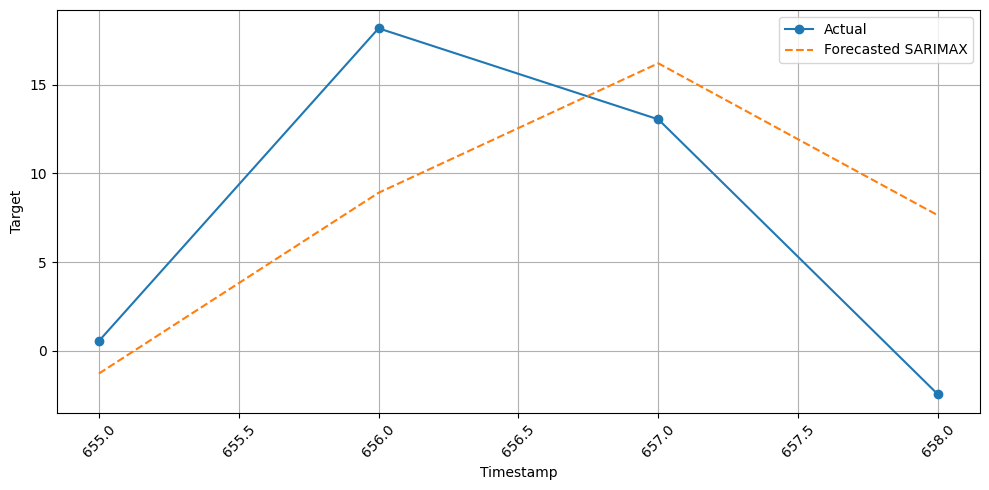

In [108]:
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'],
                order=(4, 0, 0),
                seasonal_order=(1, 0, 1, 8),
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [109]:
# Output the MSE and MAPE values
sarima_mse, sarima_mape

(6.0923741217197716, 2.0538005496550618)

In [110]:
data_path = '/content/reference.xlsx'
reference = pd.read_excel(data_path)

In [111]:
data_path = '/content/summed_up.xlsx'
summed_up = pd.read_excel(data_path)

   Combined_Sum
0     38.824675
1     49.726463
2     53.831565
3     37.932895
MAE: 6.55
MAPE: 17.29%


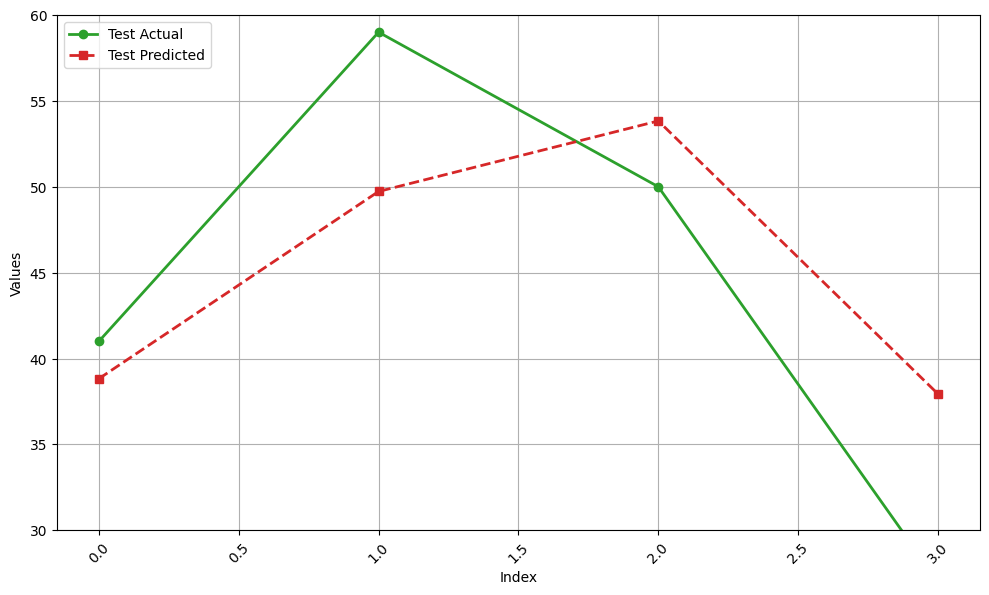

In [112]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

In [113]:
y_true = test      # or your true series
y_pred = predicted       # your predictions aligned with y_true


In [114]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def regression_metrics(y_true, y_pred):
    """
    y_true, y_pred: array-like, same length
    Returns a dict with MAE, RMSE, MAPE (%), SMAPE (%), MASE.
    MASE is computed against a naive (random walk) forecast: y_hat_t = y_{t-1}.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Basic checks
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shapes differ: y_true {y_true.shape}, y_pred {y_pred.shape}")

    # 1) MAE
    mae = mean_absolute_error(y_true, y_pred)

    # 2) RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # 3) MAPE (sklearn returns fraction → convert to %)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0

    # 4) SMAPE (%)
    diff = np.abs(y_pred - y_true)
    denom = np.abs(y_true) + np.abs(y_pred)
    # avoid division by zero
    nonzero = denom > 0
    smape = np.nan
    if np.any(nonzero):
        smape = 100.0 * np.mean(2.0 * diff[nonzero] / denom[nonzero])

    # 5) MASE (vs naive y_{t-1})
    # Naive forecast: y_hat_t = y_{t-1}, for t >= 1
    if len(y_true) > 1:
        naive_true = y_true[1:]
        naive_pred = y_true[:-1]
        naive_mae = mean_absolute_error(naive_true, naive_pred)
        mase = mae / naive_mae if naive_mae != 0 else np.nan
    else:
        mase = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_percent": mape,
        "SMAPE_percent": smape,
        "MASE": mase,
    }


In [115]:
metrics = regression_metrics(y_true, y_pred)

print("Regression Metrics")
for name, value in metrics.items():
    print(f"{name:14s}: {value:10.4f}")


Regression Metrics
MAE           :     6.5533
RMSE          :     7.4990
MAPE_percent  :    17.2947
SMAPE_percent :    15.8909
MASE          :     0.3932
